In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)

In [2]:
# Load Dataset
df = pd.read_excel("email_classification_dataset.xlsx")

In [3]:
df.head()

,id,email_text,category,sentiment,priority
0,1,I was charged for a service I never used. Please process a refund of $499 to my account.,Refund,Negative,Medium
1,2,My account shows incorrect subscription status. It shows free plan but I am on the premium plan.,Account,Neutral,High
2,3,"I was promised a callback within 24 hours on December 15, 2025 but no one called. This is unacceptable.",Complaint,Negative,High
3,4,"I was charged a late fee of ₹10,000 even though my payment was submitted on time. Please waive this fee.",Billing,Negative,High
4,5,Video calls on your platform drop after exactly 10 minutes. This is affecting my work meetings.,Technical,Neutral,High


In [4]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape:
(5100, 5)

Rows: 5100
Columns: 5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5100 non-null   int64 
 1   email_text  5100 non-null   object
 2   category    5100 non-null   object
 3   sentiment   5100 non-null   object
 4   priority    5100 non-null   object
dtypes: int64(1), object(4)
memory usage: 199.3+ KB


In [6]:
# Missing Values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

id            0
email_text    0
category      0
sentiment     0
priority      0
dtype: int64


In [7]:
# Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
# Category Distribution
category_counts = df['category'].value_counts()

print(category_counts)

category
Technical          800
Billing            780
Account            750
General Inquiry    750
Complaint          720
Refund             680
Feedback           620
Name: count, dtype: int64


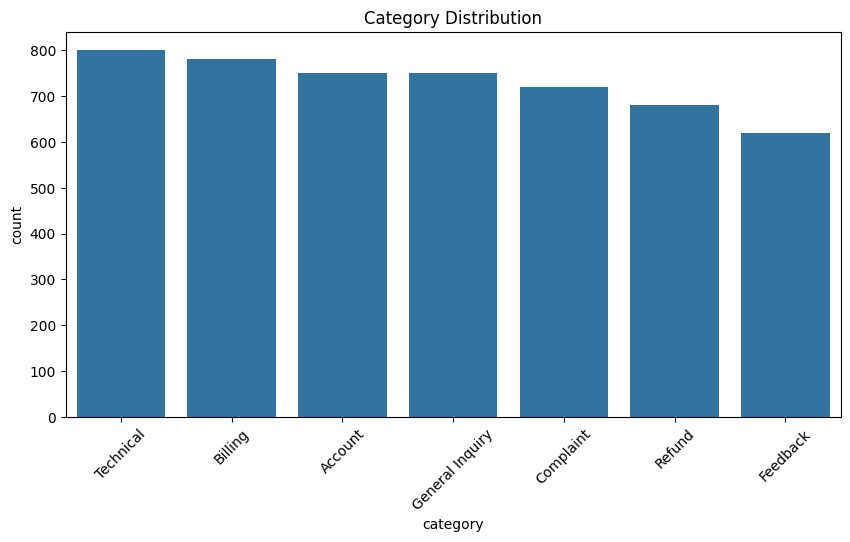

In [9]:
# Category Visualization
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='category',
    order=df['category'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Category Distribution")
plt.show()

In [10]:
# Calculate Email Length
df['email_length'] = df['email_text'].apply(
    lambda x: len(str(x).split())
)

In [11]:
print("="*50)
print("EDA SUMMARY")
print("="*50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nCategory Distribution:")
print(df['category'].value_counts())

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nPriority Distribution:")
print(df['priority'].value_counts())

print("\nAverage Email Length:")
print(round(df['email_length'].mean(),2))

EDA SUMMARY
Rows: 5100
Columns: 6

Missing Values:
id              0
email_text      0
category        0
sentiment       0
priority        0
email_length    0
dtype: int64

Duplicate Rows:
0

Category Distribution:
category
Technical          800
Billing            780
Account            750
General Inquiry    750
Complaint          720
Refund             680
Feedback           620
Name: count, dtype: int64

Sentiment Distribution:
sentiment
Negative    2502
Neutral     2114
Positive     484
Name: count, dtype: int64

Priority Distribution:
priority
High        2175
Medium      1138
Critical     989
Low          798
Name: count, dtype: int64

Average Email Length:
16.68


**Step 3**

In [12]:
# View Raw Emails
for i in range(5):
    print(f"\nEmail {i+1}")
    print("-"*80)
    print(df['email_text'].iloc[i])


Email 1
--------------------------------------------------------------------------------
I was charged for a service I never used. Please process a refund of $499 to my account.

Email 2
--------------------------------------------------------------------------------
My account shows incorrect subscription status. It shows free plan but I am on the premium plan.

Email 3
--------------------------------------------------------------------------------
I was promised a callback within 24 hours on December 15, 2025 but no one called. This is unacceptable.

Email 4
--------------------------------------------------------------------------------
I was charged a late fee of ₹10,000 even though my payment was submitted on time. Please waive this fee.

Email 5
--------------------------------------------------------------------------------
Video calls on your platform drop after exactly 10 minutes. This is affecting my work meetings.


In [13]:
# Random Raw Emails
df['email_text'].sample(10).tolist()

['I was overcharged by ₹3,500 on my last order. Please refund the excess amount to my card.',
 'Please initiate a refund for duplicate payment of $49.99 that was made due to a technical glitch.',
 'I am getting error code 403 Forbidden when trying to log in to the system. This has been happening since June 1, 2026.',
 'Can you please tell me about the pricing plans available for enterprise customers with more than 50 users?',
 'Can you confirm if your service is available in Canada and if pricing is in local currency?',
 'I want to enable two-factor authentication on my account but the option is not available.',
 'I am getting error code 403 Forbidden when trying to log in to the system. This has been happening since May 7, 2026.',
 'The new user interface update is confusing and not user-friendly. Please consider reverting to the old design.',
 'The integration with third-party tools like Salesforce would make your product much more useful for teams.',
 'I need a GST invoice for my pa

In [14]:
# Word Count Statistics
word_counts = df['email_text'].apply(
    lambda x: len(str(x).split())
)

print(word_counts.describe())

count    5100.000000
mean       16.683725
std         1.871790
min        11.000000
25%        16.000000
50%        17.000000
75%        18.000000
max        23.000000
Name: email_text, dtype: float64


In [15]:
# Character Count Statistics
char_counts = df['email_text'].apply(
    lambda x: len(str(x))
)

print(char_counts.describe())

count    5100.000000
mean       96.612157
std         8.732148
min        73.000000
25%        90.000000
50%        96.000000
75%       102.000000
max       123.000000
Name: email_text, dtype: float64


In [16]:
# Vocabulary Size
all_words = " ".join(
    df['email_text'].astype(str)
).split()

unique_words = set(all_words)

print("Total Words:", len(all_words))
print("Unique Words:", len(unique_words))

Total Words: 85087
Unique Words: 919


In [17]:
# Most Frequent Words
from collections import Counter

word_freq = Counter(all_words)

word_freq.most_common(30)

[('I', 3338),
 ('my', 2753),
 ('the', 2683),
 ('to', 2670),
 ('The', 1876),
 ('is', 1595),
 ('a', 1551),
 ('for', 1499),
 ('was', 1243),
 ('and', 1212),
 ('Please', 1168),
 ('on', 1166),
 ('of', 1138),
 ('not', 1118),
 ('your', 1048),
 ('refund', 751),
 ('My', 664),
 ('account', 635),
 ('but', 615),
 ('am', 594),
 ('with', 581),
 ('have', 545),
 ('are', 526),
 ('has', 507),
 ('from', 469),
 ('been', 464),
 ('need', 456),
 ('product', 443),
 ('in', 441),
 ('What', 415)]

In [18]:
# Check URLs
import re

url_count = df['email_text'].str.contains(
    r'http|www',
    case=False,
    regex=True
).sum()

print("Emails containing URLs:", url_count)

Emails containing URLs: 0


In [19]:
# Check Email Addresses
email_count = df['email_text'].str.contains(
    r'@',
    regex=True
).sum()

print("Emails containing Email IDs:", email_count)

Emails containing Email IDs: 86


In [20]:
# Check Numbers
number_count = df['email_text'].str.contains(
    r'\d',
    regex=True
).sum()

print("Emails containing Numbers:", number_count)

Emails containing Numbers: 2439


In [21]:
# Check Special Characters
special_char_count = df['email_text'].str.contains(
    r'[^A-Za-z0-9\s]',
    regex=True
).sum()

print("Emails with Special Characters:", special_char_count)

Emails with Special Characters: 5100


In [22]:
# Longest Email
longest_index = df['email_length'].idxmax()

print(df.loc[longest_index,'email_text'])

I am getting error code 403 Forbidden when trying to log in to the system. This has been happening since June 1, 2026.


In [23]:
# Shortest Email
shortest_index = df['email_length'].idxmin()

print(df.loc[shortest_index,'email_text'])

Do you offer any discounts for educational institutions or non-profit organizations?


In [24]:
# Category-wise Sample Inspection
for category in df['category'].unique():

    print("\n")
    print("="*80)
    print(category)
    print("="*80)

    sample = df[df['category']==category]['email_text'].sample(3)

    for text in sample:
        print(text)
        print()



Refund
I was charged for a service I never used. Please process a refund of $499 to my account.

The product I received was completely different from what was described on your website. I need a refund.

I was charged for a service I never used. Please process a refund of ₹15,000 to my account.



Account
My profile picture is not updating despite uploading multiple times. The old photo keeps showing.

My account was suspended without any prior notice or explanation. Please tell me the reason.

My profile picture is not updating despite uploading multiple times. The old photo keeps showing.



Complaint
I have been waiting for a resolution for 5 days and no one has bothered to follow up with me.

The response time from your support team is completely unacceptable. I waited 48 hours for a simple reply.

I feel cheated by your company. The subscription auto-renewed without my consent or any prior notification.



Billing
I need to change my payment method from credit card to bank trans

**Step 4**

In [25]:
# Create Cleaning Function
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = re.sub(r'\S+@\S+', ' ', text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    text = text.strip()

    return text

In [26]:
df['clean_text'] = df['email_text'].apply(clean_text)

In [27]:
for i in range(5):

    print("="*100)

    print("ORIGINAL:")
    print(df['email_text'].iloc[i])

    print("\nCLEANED:")
    print(df['clean_text'].iloc[i])

    print("\n")

ORIGINAL:
I was charged for a service I never used. Please process a refund of $499 to my account.

CLEANED:
i was charged for a service i never used please process a refund of to my account


ORIGINAL:
My account shows incorrect subscription status. It shows free plan but I am on the premium plan.

CLEANED:
my account shows incorrect subscription status it shows free plan but i am on the premium plan


ORIGINAL:
I was promised a callback within 24 hours on December 15, 2025 but no one called. This is unacceptable.

CLEANED:
i was promised a callback within hours on december but no one called this is unacceptable


ORIGINAL:
I was charged a late fee of ₹10,000 even though my payment was submitted on time. Please waive this fee.

CLEANED:
i was charged a late fee of even though my payment was submitted on time please waive this fee


ORIGINAL:
Video calls on your platform drop after exactly 10 minutes. This is affecting my work meetings.

CLEANED:
video calls on your platform drop after

In [28]:
df['clean_text'].isnull().sum()

np.int64(0)

In [29]:
df.to_csv(
    "email_cleaned.csv",
    index=False
)

**Step 5**

In [30]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [31]:
from nltk.tokenize import word_tokenize

In [32]:
sample_text = df['clean_text'].iloc[0]

print(sample_text)

tokens = word_tokenize(sample_text)

print("\nTokens:")
print(tokens)

i was charged for a service i never used please process a refund of to my account

Tokens:
['i', 'was', 'charged', 'for', 'a', 'service', 'i', 'never', 'used', 'please', 'process', 'a', 'refund', 'of', 'to', 'my', 'account']


In [33]:
# Tokenize One Sample Email
sample_text = df['clean_text'].iloc[0]

print(sample_text)

tokens = word_tokenize(sample_text)

print("\nTokens:")
print(tokens)

i was charged for a service i never used please process a refund of to my account

Tokens:
['i', 'was', 'charged', 'for', 'a', 'service', 'i', 'never', 'used', 'please', 'process', 'a', 'refund', 'of', 'to', 'my', 'account']


In [34]:
# Compare Original vs Tokens
for i in range(3):

    print("="*80)

    text = df['clean_text'].iloc[i]

    print("TEXT:")
    print(text)

    print("\nTOKENS:")
    print(word_tokenize(text))

    print("\n")

TEXT:
i was charged for a service i never used please process a refund of to my account

TOKENS:
['i', 'was', 'charged', 'for', 'a', 'service', 'i', 'never', 'used', 'please', 'process', 'a', 'refund', 'of', 'to', 'my', 'account']


TEXT:
my account shows incorrect subscription status it shows free plan but i am on the premium plan

TOKENS:
['my', 'account', 'shows', 'incorrect', 'subscription', 'status', 'it', 'shows', 'free', 'plan', 'but', 'i', 'am', 'on', 'the', 'premium', 'plan']


TEXT:
i was promised a callback within hours on december but no one called this is unacceptable

TOKENS:
['i', 'was', 'promised', 'a', 'callback', 'within', 'hours', 'on', 'december', 'but', 'no', 'one', 'called', 'this', 'is', 'unacceptable']




In [35]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [36]:
df[['clean_text','tokens']].head()

,clean_text,tokens
0,i was charged for a service i never used please process a refund of to my account,"[i, was, charged, for, a, service, i, never, used, please, process, a, refund, of, to, my, account]"
1,my account shows incorrect subscription status it shows free plan but i am on the premium plan,"[my, account, shows, incorrect, subscription, status, it, shows, free, plan, but, i, am, on, the, premium, plan]"
2,i was promised a callback within hours on december but no one called this is unacceptable,"[i, was, promised, a, callback, within, hours, on, december, but, no, one, called, this, is, unacceptable]"
3,i was charged a late fee of even though my payment was submitted on time please waive this fee,"[i, was, charged, a, late, fee, of, even, though, my, payment, was, submitted, on, time, please, waive, this, fee]"
4,video calls on your platform drop after exactly minutes this is affecting my work meetings,"[video, calls, on, your, platform, drop, after, exactly, minutes, this, is, affecting, my, work, meetings]"


In [37]:
df.to_csv(
    "email_tokenized.csv",
    index=False
)

**Step 6**

In [38]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [39]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print("Total Stopwords:", len(stop_words))

Total Stopwords: 198


In [42]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [43]:
# Remove Stopwords from One Email
sample_tokens = df['tokens'].iloc[0]

filtered_tokens = [
    word
    for word in sample_tokens
    if word not in stop_words
]

print("Before:")
print(sample_tokens)

print("\nAfter:")
print(filtered_tokens)

Before:
['i', 'was', 'charged', 'for', 'a', 'service', 'i', 'never', 'used', 'please', 'process', 'a', 'refund', 'of', 'to', 'my', 'account']

After:
['charged', 'service', 'never', 'used', 'please', 'process', 'refund', 'account']


In [44]:
# Create Stopword Removal Function
def remove_stopwords(tokens):

    return [
        word
        for word in tokens
        if word not in stop_words
    ]

In [45]:
df['tokens_no_stopwords'] = df['tokens'].apply(
    remove_stopwords
)

In [46]:
df[
    [
        'tokens',
        'tokens_no_stopwords'
    ]
].head()

,tokens,tokens_no_stopwords
0,"[i, was, charged, for, a, service, i, never, used, please, process, a, refund, of, to, my, account]","[charged, service, never, used, please, process, refund, account]"
1,"[my, account, shows, incorrect, subscription, status, it, shows, free, plan, but, i, am, on, the, premium, plan]","[account, shows, incorrect, subscription, status, shows, free, plan, premium, plan]"
2,"[i, was, promised, a, callback, within, hours, on, december, but, no, one, called, this, is, unacceptable]","[promised, callback, within, hours, december, one, called, unacceptable]"
3,"[i, was, charged, a, late, fee, of, even, though, my, payment, was, submitted, on, time, please, waive, this, fee]","[charged, late, fee, even, though, payment, submitted, time, please, waive, fee]"
4,"[video, calls, on, your, platform, drop, after, exactly, minutes, this, is, affecting, my, work, meetings]","[video, calls, platform, drop, exactly, minutes, affecting, work, meetings]"


In [47]:
df.to_csv(
    "email_stopwords_removed.csv",
    index=False
)

**Step 7**

In [48]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [49]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [50]:
words = [
    "failed",
    "failing",
    "fails",
    "payments",
    "issues",
    "accounts"
]

for word in words:
    print(word, " --> ", lemmatizer.lemmatize(word))

failed  -->  failed
failing  -->  failing
fails  -->  fails
payments  -->  payment
issues  -->  issue
accounts  -->  account


In [51]:
def lemmatize_tokens(tokens):

    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

In [52]:
df['lemmatized_tokens'] = df[
    'tokens_no_stopwords'
].apply(
    lemmatize_tokens
)

In [53]:
df[
    [
        'tokens_no_stopwords',
        'lemmatized_tokens'
    ]
].head()

,tokens_no_stopwords,lemmatized_tokens
0,"[charged, service, never, used, please, process, refund, account]","[charged, service, never, used, please, process, refund, account]"
1,"[account, shows, incorrect, subscription, status, shows, free, plan, premium, plan]","[account, show, incorrect, subscription, status, show, free, plan, premium, plan]"
2,"[promised, callback, within, hours, december, one, called, unacceptable]","[promised, callback, within, hour, december, one, called, unacceptable]"
3,"[charged, late, fee, even, though, payment, submitted, time, please, waive, fee]","[charged, late, fee, even, though, payment, submitted, time, please, waive, fee]"
4,"[video, calls, platform, drop, exactly, minutes, affecting, work, meetings]","[video, call, platform, drop, exactly, minute, affecting, work, meeting]"


In [54]:
df.to_csv(
    "email_lemmatized.csv",
    index=False
)

**Step 8**

In [55]:
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [56]:
from nltk import pos_tag

In [57]:
sample_tokens = df[
    'lemmatized_tokens'
].iloc[0]

tagged_tokens = pos_tag(sample_tokens)

print(tagged_tokens)

[('charged', 'VBN'), ('service', 'NN'), ('never', 'RB'), ('used', 'VBD'), ('please', 'NN'), ('process', 'NN'), ('refund', 'NN'), ('account', 'NN')]


In [58]:
def get_pos_tags(tokens):

    return pos_tag(tokens)

In [59]:
df['pos_tags'] = df[
    'lemmatized_tokens'
].apply(
    get_pos_tags
)

In [60]:
df[
    [
        'lemmatized_tokens',
        'pos_tags'
    ]
].head()

,lemmatized_tokens,pos_tags
0,"[charged, service, never, used, please, process, refund, account]","[(charged, VBN), (service, NN), (never, RB), (used, VBD), (please, NN), (process, NN), (refund, NN), (account, NN)]"
1,"[account, show, incorrect, subscription, status, show, free, plan, premium, plan]","[(account, NN), (show, NN), (incorrect, JJ), (subscription, NN), (status, NN), (show, VBP), (free, JJ), (plan, NN), (premium, NN), (plan, NN)]"
2,"[promised, callback, within, hour, december, one, called, unacceptable]","[(promised, VBN), (callback, NN), (within, IN), (hour, NN), (december, VBP), (one, CD), (called, VBN), (unacceptable, JJ)]"
3,"[charged, late, fee, even, though, payment, submitted, time, please, waive, fee]","[(charged, VBN), (late, JJ), (fee, NN), (even, RB), (though, IN), (payment, NN), (submitted, VBN), (time, NN), (please, NN), (waive, JJ), (fee, NN)]"
4,"[video, call, platform, drop, exactly, minute, affecting, work, meeting]","[(video, NN), (call, NN), (platform, NN), (drop, NN), (exactly, RB), (minute, JJ), (affecting, VBG), (work, NN), (meeting, NN)]"


In [61]:
df.to_csv(
    "email_pos_tagged.csv",
    index=False
)

**Step 9**

In [62]:
!pip install -q spacy

In [63]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [64]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [65]:
text = """
I paid ₹5000 to Paytm on 5 June 2026.
"""

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, " --> ", ent.label_)

5000  -->  MONEY
5 June 2026  -->  DATE


In [66]:
sample_email = df['email_text'].iloc[0]

doc = nlp(sample_email)

for ent in doc.ents:
    print(ent.text, " --> ", ent.label_)

499  -->  MONEY


In [67]:
def extract_entities(text):

    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:

        entities.append(
            {
                "text": ent.text,
                "label": ent.label_
            }
        )

    return entities

In [68]:
df['entities'] = df['email_text'].apply(
    extract_entities
)

In [69]:
df[
    [
        'email_text',
        'entities'
    ]
].head()

,email_text,entities
0,I was charged for a service I never used. Please process a refund of $499 to my account.,"[{'text': '499', 'label': 'MONEY'}]"
1,My account shows incorrect subscription status. It shows free plan but I am on the premium plan.,[]
2,"I was promised a callback within 24 hours on December 15, 2025 but no one called. This is unacceptable.","[{'text': '24 hours', 'label': 'TIME'}, {'text': 'December 15, 2025', 'label': 'DATE'}]"
3,"I was charged a late fee of ₹10,000 even though my payment was submitted on time. Please waive this fee.","[{'text': '10,000', 'label': 'MONEY'}]"
4,Video calls on your platform drop after exactly 10 minutes. This is affecting my work meetings.,"[{'text': 'exactly 10 minutes', 'label': 'TIME'}]"


In [70]:
from collections import Counter

entity_labels = []

for email_entities in df['entities']:

    for entity in email_entities:

        entity_labels.append(
            entity['label']
        )

Counter(entity_labels).most_common()

[('DATE', 1295),
 ('MONEY', 1184),
 ('ORG', 631),
 ('CARDINAL', 412),
 ('TIME', 239),
 ('PERSON', 186),
 ('NORP', 88),
 ('GPE', 77),
 ('LAW', 38),
 ('ORDINAL', 32),
 ('PERCENT', 31),
 ('FAC', 17),
 ('PRODUCT', 8)]

In [71]:
df.to_csv(
    "email_ner_completed.csv",
    index=False
)

**Step 10**

In [72]:
important_tags = [
    'NN',
    'NNS',
    'NNP',
    'NNPS',
    'VB',
    'VBD',
    'VBG',
    'VBN',
    'VBP',
    'VBZ',
    'JJ'
]

In [73]:
def extract_keywords(pos_tags):

    keywords = []

    for word, tag in pos_tags:

        if tag in important_tags:

            keywords.append(word)

    return keywords

In [74]:
df['keywords'] = df['pos_tags'].apply(
    extract_keywords
)

In [75]:
df[
    [
        'email_text',
        'keywords'
    ]
].head()

,email_text,keywords
0,I was charged for a service I never used. Please process a refund of $499 to my account.,"[charged, service, used, please, process, refund, account]"
1,My account shows incorrect subscription status. It shows free plan but I am on the premium plan.,"[account, show, incorrect, subscription, status, show, free, plan, premium, plan]"
2,"I was promised a callback within 24 hours on December 15, 2025 but no one called. This is unacceptable.","[promised, callback, hour, december, called, unacceptable]"
3,"I was charged a late fee of ₹10,000 even though my payment was submitted on time. Please waive this fee.","[charged, late, fee, payment, submitted, time, please, waive, fee]"
4,Video calls on your platform drop after exactly 10 minutes. This is affecting my work meetings.,"[video, call, platform, drop, minute, affecting, work, meeting]"


In [76]:
for i in range(5):

    sample = df.sample(1)

    print("="*100)

    print("EMAIL:")
    print(sample['email_text'].values[0])

    print("\nKEYWORDS:")
    print(sample['keywords'].values[0])

    print("\n")

EMAIL:
The video tutorials on your website are outdated and do not reflect the current version of the software.

KEYWORDS:
['video', 'tutorial', 'website', 'outdated', 'reflect', 'current', 'version', 'software']


EMAIL:
I want to share positive feedback about your customer support agent Michael who was extremely helpful.

KEYWORDS:
['want', 'share', 'positive', 'feedback', 'customer', 'support', 'agent', 'michael', 'helpful']


EMAIL:
Can you please tell me about the pricing plans available for enterprise customers with more than 100 users?

KEYWORDS:
['please', 'tell', 'pricing', 'plan', 'available', 'enterprise', 'customer', 'user']


EMAIL:
I have been waiting for my refund of ₹2,000 for over 21 days. Please expedite the process.

KEYWORDS:
['waiting', 'refund', 'day', 'please', 'expedite', 'process']


EMAIL:
I have not received my refund of $149 that was approved on March 3, 2026. Please provide an update.

KEYWORDS:
['received', 'refund', 'approved', 'march', 'please', 'provide

In [77]:
df.to_csv(
    "email_keywords_extracted.csv",
    index=False
)

**Step 11**

In [78]:
df['processed_text'] = df['lemmatized_tokens'].apply(
    lambda x: " ".join(x)
)

In [79]:
df[
    [
        'lemmatized_tokens',
        'processed_text'
    ]
].head()

,lemmatized_tokens,processed_text
0,"[charged, service, never, used, please, process, refund, account]",charged service never used please process refund account
1,"[account, show, incorrect, subscription, status, show, free, plan, premium, plan]",account show incorrect subscription status show free plan premium plan
2,"[promised, callback, within, hour, december, one, called, unacceptable]",promised callback within hour december one called unacceptable
3,"[charged, late, fee, even, though, payment, submitted, time, please, waive, fee]",charged late fee even though payment submitted time please waive fee
4,"[video, call, platform, drop, exactly, minute, affecting, work, meeting]",video call platform drop exactly minute affecting work meeting


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [81]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [82]:
X = tfidf.fit_transform(
    df['processed_text']
)

In [83]:
print(X.shape)

(5100, 579)


In [84]:
print(
    len(
        tfidf.vocabulary_
    )
)

579


In [85]:
list(
    tfidf.vocabulary_.keys()
)[:50]

['charged',
 'service',
 'never',
 'used',
 'please',
 'process',
 'refund',
 'account',
 'show',
 'incorrect',
 'subscription',
 'status',
 'free',
 'plan',
 'premium',
 'promised',
 'callback',
 'within',
 'hour',
 'december',
 'one',
 'called',
 'unacceptable',
 'late',
 'fee',
 'even',
 'though',
 'payment',
 'submitted',
 'time',
 'waive',
 'video',
 'call',
 'platform',
 'drop',
 'exactly',
 'minute',
 'affecting',
 'work',
 'meeting',
 'happens',
 'data',
 'decide',
 'cancel',
 'long',
 'retained',
 'delivered',
 'requesting',
 'partial',
 'custom']

In [86]:
y = df['category']

In [87]:
y.value_counts()

,count
category,
Technical,800
Billing,780
Account,750
General Inquiry,750
Complaint,720
Refund,680
Feedback,620


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Step 12**

In [89]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import time

In [90]:
models = {

    "Naive Bayes":
        MultinomialNB(),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Linear SVM":
        LinearSVC(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

In [91]:
results = []

for name, model in models.items():

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    end_time = time.time()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    training_time = round(
        end_time - start_time,
        2
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])

In [92]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Naive Bayes,1.0,1.0,1.0,1.0,0.04
1,Logistic Regression,1.0,1.0,1.0,1.0,0.25
2,Linear SVM,1.0,1.0,1.0,1.0,0.39
3,Random Forest,1.0,1.0,1.0,1.0,0.62


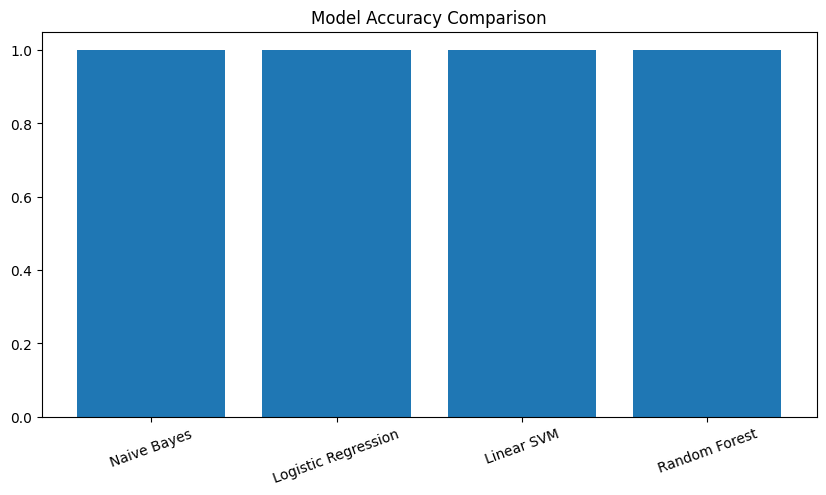

In [93]:
import matplotlib.pyplot as plt

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=20)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

In [95]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [97]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [96]:
y_pred = model.predict(X_test)

In [98]:
y_pred = nb_model.predict(X_test)

In [99]:
accuracy = nb_model.score(X_test, y_test)

In [101]:
new_emails = [

    "My payment failed and money was deducted",

    "I cannot login to my account",

    "Please refund my order immediately",

    "The application crashes while making payment",

    "Thank you for the excellent support"
]

In [102]:
processed_emails = []

for email in new_emails:

    cleaned = clean_text(email)

    tokens = word_tokenize(cleaned)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    lemmas = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    processed_emails.append(
        " ".join(lemmas)
    )

In [103]:
new_vectors = tfidf.transform(
    processed_emails
)

In [104]:
print(new_vectors.shape)

(5, 579)


In [105]:
predictions = nb_model.predict(
    new_vectors
)

In [106]:
for email, prediction in zip(
    new_emails,
    predictions
):

    print("="*80)

    print("Email:")
    print(email)

    print("\nPredicted Category:")
    print(prediction)

    print()

Email:
My payment failed and money was deducted

Predicted Category:
Billing

Email:
I cannot login to my account

Predicted Category:
Account

Email:
Please refund my order immediately

Predicted Category:
Billing

Email:
The application crashes while making payment

Predicted Category:
Technical

Email:
Thank you for the excellent support

Predicted Category:
Feedback



In [107]:
new_vectors = tfidf.transform(processed_emails)

In [108]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_text'])

**Step 14**

In [109]:
import joblib

In [110]:
joblib.dump(
    nb_model,
    "naive_bayes_model.pkl"
)

['naive_bayes_model.pkl']

In [111]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [112]:
import os

print(os.listdir())

['.config', 'email_classification_dataset.xlsx', 'tfidf_vectorizer.pkl', 'email_ner_completed.csv', 'email_keywords_extracted.csv', 'email_tokenized.csv', 'naive_bayes_model.pkl', 'email_lemmatized.csv', 'email_cleaned.csv', 'email_pos_tagged.csv', 'email_stopwords_removed.csv', 'sample_data']


**Testing the model**

In [113]:
loaded_model = joblib.load(
    "naive_bayes_model.pkl"
)

In [114]:
loaded_tfidf = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [115]:
sample_email = [
    "My payment failed and money was deducted"
]

In [116]:
sample_vector = loaded_tfidf.transform(
    sample_email
)

In [117]:
prediction = loaded_model.predict(
    sample_vector
)

print(prediction)

['Billing']


**Step 15**

In [118]:
import joblib

loaded_model = joblib.load(
    "naive_bayes_model.pkl"
)

loaded_tfidf = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [119]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re

In [120]:
stop_words = set(
    stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

In [121]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

In [122]:
def predict_email_category(email):

    cleaned = clean_text(email)

    tokens = word_tokenize(cleaned)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    lemmas = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    processed_text = " ".join(
        lemmas
    )

    vector = loaded_tfidf.transform(
        [processed_text]
    )

    prediction = loaded_model.predict(
        vector
    )[0]

    return prediction

In [123]:
email = """
My payment failed and money was deducted
"""

result = predict_email_category(
    email
)

print(result)

Billing


In [124]:
emails = [

    "I cannot login to my account",

    "Please refund my money immediately",

    "The application crashes during payment",

    "Thank you for your excellent service",

    "I have a complaint regarding the support team"
]

In [125]:
for email in emails:

    prediction = predict_email_category(
        email
    )

    print("="*80)

    print("Email:")
    print(email)

    print("\nPrediction:")
    print(prediction)

    print()

Email:
I cannot login to my account

Prediction:
Account

Email:
Please refund my money immediately

Prediction:
Billing

Email:
The application crashes during payment

Prediction:
Technical

Email:
Thank you for your excellent service

Prediction:
Feedback

Email:
I have a complaint regarding the support team

Prediction:
Complaint



In [126]:
def predict_with_confidence(email):

    cleaned = clean_text(email)

    tokens = word_tokenize(cleaned)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    lemmas = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    processed_text = " ".join(
        lemmas
    )

    vector = loaded_tfidf.transform(
        [processed_text]
    )

    prediction = loaded_model.predict(
        vector
    )[0]

    confidence = max(
        loaded_model.predict_proba(
            vector
        )[0]
    )

    return prediction, confidence

In [127]:
category, confidence = predict_with_confidence(
    "My payment failed and money was deducted"
)

print("Category:", category)

print(
    "Confidence:",
    round(confidence*100,2),
    "%"
)

Category: Billing
Confidence: 98.19 %
